# 5 at% (IT2) — Filtering Pipeline

**Stage 1 — Weak filtering (universal):**
- Single-phase BCC at 500/600/650°C **AND** RT thermal conductivity (THCD) > 16 W/(m·K)
- Build KNN graph, identify connected subgraphs (Subgraph 1, 2, 3 …)
- Output: one master CSV (with `subgraph` column) + one CSV per subgraph + one plot

**Stage 2 — Subgraph 1 → Alloy A/B/AB filtering:**
- Take Subgraph 1 only (the largest, FGM-friendly cluster)
- Apply Alloy A (Solidus > 2200°C) and Alloy B (Pugh ≥ 2.6)
- Output: one CSV with `category` column + one categorical plot + one continuous-property plot

## 1. Imports + configuration

In [113]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon

%matplotlib inline

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['STIXGeneral', 'Times', 'Computer Modern Roman'],
    'font.size': 10,
    'axes.labelsize': 10,
    'text.usetex': False,
    'lines.linewidth': 2.0,
    'lines.markersize': 6,
    'axes.linewidth': 1.0,
    'axes.formatter.useoffset': False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'legend.fontsize': 10,
    'legend.frameon': False,
    'figure.constrained_layout.use': False,
})

In [114]:
INPUT_CSV = r'C:\Users\ifada\OneDrive - Texas A&M University\CHD_FRAMEWORK\FILTERING\FLARE-survivors-5at-10x_equil.csv'

OUT_PREFIX = 'IT2'

ELEMENTS = ['Ti', 'V', 'Ta', 'Nb', 'Mo', 'Zr', 'Cr', 'Hf', 'Fe', 'Re', 'W']

TEMPS_BCC      = [500, 600, 650]
BCC_THRESHOLD  = 0.98
THCD_RT_MIN    = 16.0

K_NEIGHBORS    = 12
USE_RADIUS     = True
RADIUS         = 0.16

ALLOY_A_SOLIDUS_K   = 2200 + 273.15
ALLOY_B_PUGH_MIN    = 2.6

COL_COMPOSITION  = 'composition'
COL_SOLIDUS_K    = 'PROP ST (K)'
COL_THCD_RT      = 'PROP 25C THCD (W/(mK))'
COL_PUGH         = 'Pugh_Ratio_PRIOR'

## 2. Load combined data

In [115]:
print(f'Loading: {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)
print(f'  rows: {len(df):,}, cols: {len(df.columns)}')

expected = [COL_COMPOSITION, COL_SOLIDUS_K, COL_THCD_RT, COL_PUGH] + ELEMENTS
missing = [c for c in expected if c not in df.columns]
if missing:
    print(f'\nWARNING: missing expected columns: {missing}')
    print(f'Available columns (first 30): {df.columns[:30].tolist()}')
else:
    print('All required columns present.')

Loading: C:\Users\ifada\OneDrive - Texas A&M University\CHD_FRAMEWORK\FILTERING\FLARE-survivors-5at-10x_equil.csv
  rows: 61,507, cols: 373
All required columns present.


In [116]:
for T in TEMPS_BCC:
    bcc_cols = [c for c in df.columns
                if f'{T}C' in c and 'BCC' in c and c.strip().endswith('MOL')]
    if not bcc_cols:
        raise ValueError(f'No BCC MOL columns found for {T}C. Sample columns: {df.columns[:20].tolist()}')
    df[f'EQ {T}C MAX BCC'] = (df[bcc_cols]
                              .apply(pd.to_numeric, errors='coerce')
                              .fillna(0.0)
                              .max(axis=1))
    print(f'{T}C: found {len(bcc_cols)} BCC columns -> EQ {T}C MAX BCC')

500C: found 6 BCC columns -> EQ 500C MAX BCC
600C: found 6 BCC columns -> EQ 600C MAX BCC
650C: found 6 BCC columns -> EQ 650C MAX BCC


C:\Users\ifada\AppData\Local\Temp\ipykernel_47548\371936187.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'EQ {T}C MAX BCC'] = (df[bcc_cols]
C:\Users\ifada\AppData\Local\Temp\ipykernel_47548\371936187.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'EQ {T}C MAX BCC'] = (df[bcc_cols]
C:\Users\ifada\AppData\Local\Temp\ipykernel_47548\371936187.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining al

## 3. Apply weak filters

In [117]:
mask_bcc = np.ones(len(df), dtype=bool)
for T in TEMPS_BCC:
    col = f'EQ {T}C MAX BCC'
    mask_T = df[col].fillna(0) >= BCC_THRESHOLD
    print(f'  {col}: {mask_T.sum():,} pass (>= {BCC_THRESHOLD})')
    mask_bcc &= mask_T
print(f'BCC stable across all {len(TEMPS_BCC)} temps: {mask_bcc.sum():,}')

mask_thcd = df[COL_THCD_RT].fillna(-1) > THCD_RT_MIN
print(f'THCD at 25C > {THCD_RT_MIN}: {mask_thcd.sum():,} pass')

mask_weak = mask_bcc & mask_thcd
df_weak = df.loc[mask_weak].copy().reset_index(drop=True)
print(f'\nWeak filter survivors: {len(df_weak):,}')

  EQ 500C MAX BCC: 661 pass (>= 0.98)
  EQ 600C MAX BCC: 1,096 pass (>= 0.98)
  EQ 650C MAX BCC: 1,387 pass (>= 0.98)
BCC stable across all 3 temps: 661
THCD at 25C > 16.0: 51,644 pass

Weak filter survivors: 657


## 4. Build KNN graph

In [118]:
def pairwise_knn_edges(X, k=12, radius=None):
    n = X.shape[0]
    sq = np.sum(X*X, axis=1, keepdims=True)
    dist_sq = sq + sq.T - 2.0 * (X @ X.T)
    np.fill_diagonal(dist_sq, np.inf)
    edges = set()
    for i in range(n):
        nbrs = np.argpartition(dist_sq[i], k)[:k]
        if radius is not None:
            nbrs = [j for j in nbrs if dist_sq[i, j] <= radius*radius]
        for j in nbrs:
            a, b = (i, j) if i < j else (j, i)
            edges.add((a, b))
    return list(edges)

X = df_weak[ELEMENTS].fillna(0.0).to_numpy(dtype=float)
rowsum = X.sum(axis=1, keepdims=True)
rowsum[rowsum == 0] = 1.0
X = X / rowsum

print(f'Building KNN graph for {len(df_weak):,} alloys (k={K_NEIGHBORS}, radius={RADIUS if USE_RADIUS else None})')
edges = pairwise_knn_edges(X, k=K_NEIGHBORS, radius=(RADIUS if USE_RADIUS else None))
print(f'  edges: {len(edges):,}')

G = nx.Graph()
G.add_nodes_from(df_weak.index.tolist())
G.add_edges_from(edges)

components = sorted(nx.connected_components(G), key=len, reverse=True)
print(f'\nConnected components: {len(components)}')
for i, comp in enumerate(components[:10], start=1):
    print(f'  Subgraph {i}: {len(comp):,} alloys')

Building KNN graph for 657 alloys (k=12, radius=0.16)
  edges: 4,450

Connected components: 3
  Subgraph 1: 643 alloys
  Subgraph 2: 8 alloys
  Subgraph 3: 6 alloys


In [119]:
subgraph_id = {}
for sg_idx, comp in enumerate(components, start=1):
    for node in comp:
        subgraph_id[node] = sg_idx
df_weak['subgraph'] = df_weak.index.map(subgraph_id)

rotation_angle = np.pi / 11
angles = np.linspace(0, 2*np.pi, len(ELEMENTS), endpoint=False) + rotation_angle
Q = np.column_stack([np.cos(angles), np.sin(angles)])

proj = X @ Q
df_weak['proj0'] = proj[:, 0]
df_weak['proj1'] = proj[:, 1]

POLY_VERTS = np.column_stack([np.cos(angles), np.sin(angles)])

## 5. Plot — (weak-filter subgraphs)

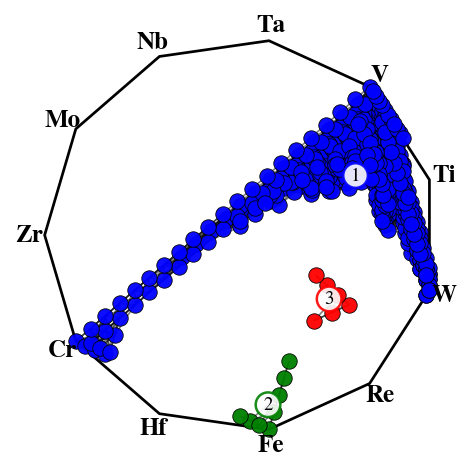

Wrote IT2_weakfilter_subgraphs.png


In [120]:
BASE_PALETTE = ['blue', 'green', 'red', 'orange', 'purple',
                'cyan', 'magenta', 'brown', 'olive', 'pink', 'gray', 'black']

def color_for_subgraph(i):
    return BASE_PALETTE[(i - 1) % len(BASE_PALETTE)]

fig, ax = plt.subplots(figsize=(4, 3))
ax.add_patch(Polygon(POLY_VERTS, closed=True, edgecolor='black', facecolor='none', linewidth=1.3))
ax.set_aspect('equal')
ax.set_xlim(-1.10, 1.10)
ax.set_ylim(-1.10, 1.10)
ax.axis('off')

for i, el in enumerate(ELEMENTS):
    x, y = POLY_VERTS[i]
    ax.text(x*1.08, y*1.08, el, ha='center', va='center',
            fontsize=12, fontweight='bold', color='black')

pos = {idx: (row.proj0, row.proj1) for idx, row in df_weak.iterrows()}
nx.draw_networkx_edges(G, pos, ax=ax, width=0.8, alpha=0.5, edge_color='black')

for i, comp in enumerate(components, start=1):
    if i > 12:
        break
    nodes = list(comp)
    color = color_for_subgraph(i)
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, ax=ax,
                           node_size=55, node_color=color, edgecolors='black',
                           linewidths=0.4, alpha=0.95)
    centroid = df_weak.loc[nodes, ['proj0', 'proj1']].mean().values
    ax.text(centroid[0], centroid[1], str(i),
            fontsize=9, ha='center', va='center',
            bbox=dict(boxstyle='circle,pad=0.2', fc='white', ec=color, lw=1.2, alpha=0.9))

plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02)
plt.savefig(f'{OUT_PREFIX}_weakfilter_subgraphs.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()
print(f'Wrote {OUT_PREFIX}_weakfilter_subgraphs.png')

## 6. Save Stage-1 outputs — master CSV + one CSV per subgraph

In [121]:
df_master = df_weak.copy()
df_master.to_csv(f'{OUT_PREFIX}_master.csv', index=False)
print(f'Wrote {OUT_PREFIX}_master.csv  ({len(df_master):,} rows, subgraph column only)')

for sg_idx in sorted(df_weak['subgraph'].dropna().unique()):
    sg_idx = int(sg_idx)
    sub_df = df_weak[df_weak['subgraph'] == sg_idx]
    fname = f'{OUT_PREFIX}_Subgraph{sg_idx}.csv'
    sub_df.to_csv(fname, index=False)
    print(f'Wrote {fname}  ({len(sub_df):,} rows)')

Wrote IT2_master.csv  (657 rows, subgraph column only)
Wrote IT2_Subgraph1.csv  (643 rows)
Wrote IT2_Subgraph2.csv  (8 rows)
Wrote IT2_Subgraph3.csv  (6 rows)


## 7. Stage 2 — Load Subgraph 1 and apply Alloy A / B / AB filtering

In [122]:
df_sub1 = pd.read_csv(f'{OUT_PREFIX}_Subgraph1.csv')
print(f'Loaded {OUT_PREFIX}_Subgraph1.csv: {len(df_sub1):,} alloys')

mask_A = df_sub1[COL_SOLIDUS_K].fillna(0) > ALLOY_A_SOLIDUS_K
print(f'Alloy A (Solidus > {ALLOY_A_SOLIDUS_K - 273.15:.0f}C): {mask_A.sum():,}')

mask_B = df_sub1[COL_PUGH].fillna(0) >= ALLOY_B_PUGH_MIN
print(f'Alloy B (Pugh >= {ALLOY_B_PUGH_MIN}): {mask_B.sum():,}')

mask_AB = mask_A & mask_B
print(f'Alloy AB (intersection): {mask_AB.sum():,}')

df_sub1['category'] = 'Intermediate'
df_sub1.loc[mask_A & ~mask_B, 'category'] = 'Alloy A'
df_sub1.loc[mask_B & ~mask_A, 'category'] = 'Alloy B'
df_sub1.loc[mask_AB,           'category'] = 'Alloy AB'
print('\nCategory counts:')
print(df_sub1['category'].value_counts())

Loaded IT2_Subgraph1.csv: 643 alloys
Alloy A (Solidus > 2200C): 152
Alloy B (Pugh >= 2.6): 344
Alloy AB (intersection): 13

Category counts:
category
Alloy B         331
Intermediate    160
Alloy A         139
Alloy AB         13
Name: count, dtype: int64


C:\Users\ifada\AppData\Local\Temp\ipykernel_47548\1258693105.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sub1['category'] = 'Intermediate'


## 8. Plot — Figure 2.6 (Subgraph 1 colored by Alloy A / B / AB)

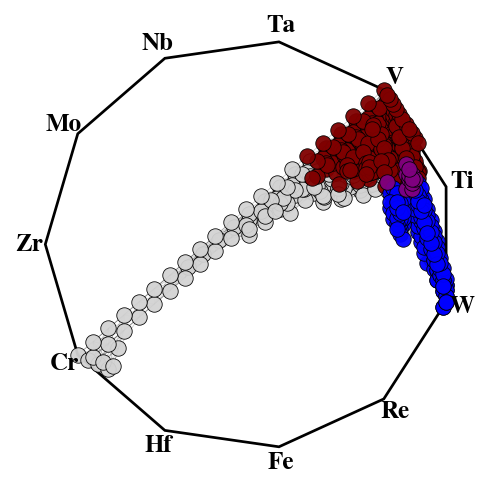

Wrote IT2_subgraph1_alloyAB.png


In [123]:
X_sub1 = df_sub1[ELEMENTS].fillna(0.0).to_numpy(dtype=float)
rs = X_sub1.sum(axis=1, keepdims=True); rs[rs == 0] = 1.0
X_sub1 = X_sub1 / rs

edges_sub1 = pairwise_knn_edges(X_sub1, k=K_NEIGHBORS, radius=(RADIUS if USE_RADIUS else None))
G_sub1 = nx.Graph()
G_sub1.add_nodes_from(df_sub1.index.tolist())
G_sub1.add_edges_from(edges_sub1)

proj_sub1 = X_sub1 @ Q
df_sub1['proj0'] = proj_sub1[:, 0]
df_sub1['proj1'] = proj_sub1[:, 1]
pos_sub1 = {idx: (df_sub1.at[idx, 'proj0'], df_sub1.at[idx, 'proj1']) for idx in df_sub1.index}

CATEGORY_COLORS = {
    'Intermediate': 'lightgray',
    'Alloy A':      'blue',
    'Alloy B':      'maroon',
    'Alloy AB':     'purple',
}

fig, ax = plt.subplots(figsize=(4, 3))
ax.add_patch(Polygon(POLY_VERTS, closed=True, edgecolor='black', facecolor='none', linewidth=1.3))
ax.set_aspect('equal')
ax.set_xlim(-1.10, 1.10)
ax.set_ylim(-1.10, 1.10)
ax.axis('off')

for i, el in enumerate(ELEMENTS):
    x, y = POLY_VERTS[i]
    ax.text(x*1.08, y*1.08, el, ha='center', va='center',
            fontsize=12, fontweight='bold', color='black')

nx.draw_networkx_edges(G_sub1, pos_sub1, ax=ax, width=0.4, alpha=0.20, edge_color='black')

for cat in ['Intermediate', 'Alloy B', 'Alloy A', 'Alloy AB']:
    sub = df_sub1[df_sub1['category'] == cat]
    if sub.empty:
        continue
    nx.draw_networkx_nodes(
        G_sub1, pos_sub1, nodelist=sub.index.tolist(), ax=ax,
        node_size=55, node_color=CATEGORY_COLORS[cat],
        edgecolors='black', linewidths=0.4, alpha=0.95
    )

plt.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.0)
plt.savefig(f'{OUT_PREFIX}_subgraph1_alloyAB.png', dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.show()
print(f'Wrote {OUT_PREFIX}_subgraph1_alloyAB.png')

## 9. Save Stage-2 output — Subgraph 1 with A/B/AB labels

In [124]:
df_sub1.to_csv(f'{OUT_PREFIX}_Subgraph1_AlloyAB.csv', index=False)
print(f'Wrote {OUT_PREFIX}_Subgraph1_AlloyAB.csv  ({len(df_sub1):,} rows with category column)')

Wrote IT2_Subgraph1_AlloyAB.csv  (643 rows with category column)


## 10. Plot — Subgraph 1 colored by continuous properties (Pugh ratio + Solidus)

Two side-by-side polygon plots of Subgraph 1:
- **(a)** Each alloy colored by **Pugh ratio (G/B)** — the Alloy B filter quantity.
- **(b)** Each alloy colored by **Solidus temperature in K** — the Alloy A filter quantity.

Viridis colormap with a colorbar for each subplot.

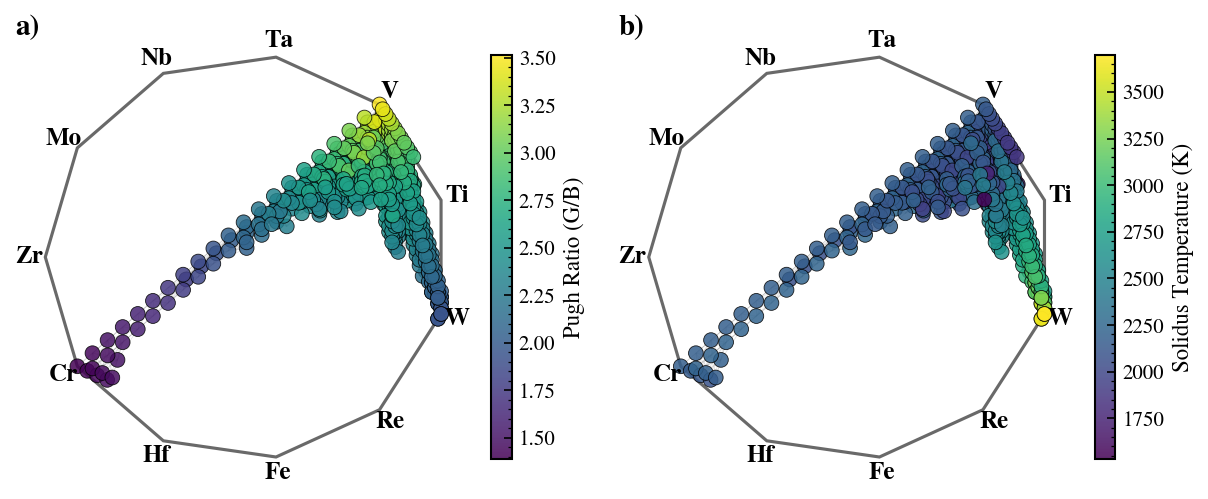

Wrote IT2_subgraph1_continuous.png


In [125]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, color_col, cbar_label in zip(
    axes,
    [COL_PUGH, COL_SOLIDUS_K],
    ['Pugh Ratio (G/B)', 'Solidus Temperature (K)'],
):
    ax.add_patch(Polygon(POLY_VERTS, closed=True, edgecolor='dimgray', facecolor='none', linewidth=1.5))
    ax.set_aspect('equal')
    ax.set_xlim(-1.10, 1.10)
    ax.set_ylim(-1.10, 1.10)
    ax.axis('off')
    for i, el in enumerate(ELEMENTS):
        x, y = POLY_VERTS[i]
        ax.text(x*1.08, y*1.08, el, ha='center', va='center',
                fontsize=12, fontweight='bold', color='black')

    nx.draw_networkx_edges(G_sub1, pos_sub1, ax=ax, width=0.4, alpha=0.20, edge_color='gray')

    sc = ax.scatter(
        df_sub1['proj0'], df_sub1['proj1'],
        c=df_sub1[color_col].astype(float),
        cmap='viridis',
        s=50, alpha=0.85, edgecolors='black', linewidths=0.4,
    )

    cbar = fig.colorbar(sc, ax=ax, shrink=0.70, pad=0.04)
    cbar.set_label(cbar_label, fontsize=11)

axes[0].text(-1.15, 1.10, 'a)', fontsize=14, fontweight='bold')
axes[1].text(-1.15, 1.10, 'b)', fontsize=14, fontweight='bold')

plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02, wspace=0.10)
plt.savefig(f'{OUT_PREFIX}_subgraph1_continuous.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()
print(f'Wrote {OUT_PREFIX}_subgraph1_continuous.png')

## 11. Quick summary

In [126]:
print(f'=== {OUT_PREFIX} pipeline summary ===')
print(f'  Input alloys (5 at% FLARE 10x):  {len(df):,}')
print(f'  After weak filters (BCC + THCD): {len(df_weak):,}')
print(f'  Subgraphs: {len(components)}')
for i, comp in enumerate(components, start=1):
    print(f'    Subgraph {i}: {len(comp):,} alloys')
print()
print(f'  Stage 2 — Subgraph 1 categorization:')
print(f'    Alloy A only:  {(df_sub1["category"] == "Alloy A").sum():,}')
print(f'    Alloy B only:  {(df_sub1["category"] == "Alloy B").sum():,}')
print(f'    Alloy AB:      {(df_sub1["category"] == "Alloy AB").sum():,}')
print(f'    Intermediate:  {(df_sub1["category"] == "Intermediate").sum():,}')

=== IT2 pipeline summary ===
  Input alloys (5 at% FLARE 10x):  61,507
  After weak filters (BCC + THCD): 657
  Subgraphs: 3
    Subgraph 1: 643 alloys
    Subgraph 2: 8 alloys
    Subgraph 3: 6 alloys

  Stage 2 — Subgraph 1 categorization:
    Alloy A only:  139
    Alloy B only:  331
    Alloy AB:      13
    Intermediate:  160
